# Clase 17: Volatilidad Implícita y Superficie de Volatilidad

> **Objetivo:** Aprender a extraer la información que el mercado está *comunicando* a través del precio de las opciones — y visualizarla en 3D.
> 

---

## 1. ¿Qué es la volatilidad implícita?

Cuando compramos o vendemos una opción, el precio que observamos en el mercado no es arbitrario. Detrás de ese precio hay una expectativa colectiva del mercado sobre cuánto se va a mover el activo subyacente de aquí al vencimiento.

La **volatilidad implícita (IV)** es esa expectativa, expresada en términos anualizados como porcentaje. No es algo que se observe directamente — hay que *extraerla* invirtiendo el modelo de Black–Scholes.

### La intuición clave

El modelo de Black–Scholes toma como inputs: precio del subyacente $S$, strike $K$, tasa libre de riesgo $r$, tiempo a vencimiento $T$ y **volatilidad $\sigma$** — y produce un precio teórico.

El problema inverso es: dado un precio de mercado real, ¿qué $\sigma$ necesita el modelo para reproducirlo?

$$
f(\sigma) = \text{BS}(S, K, r, T, \sigma) - C_{\text{mercado}} = 0
$$

Esto **no tiene solución analítica** — hay que resolverlo numéricamente.

### IV vs. Volatilidad Histórica

|  | Volatilidad Histórica | Volatilidad Implícita |
| --- | --- | --- |
| **Definición** | Desviación estándar de retornos pasados | σ que iguala BS al precio de mercado |
| **Mirada** | Hacia atrás (backward-looking) | Hacia adelante (forward-looking) |
| **Fuente** | Datos de precios históricos | Precio de mercado de la opción |
| **Uso** | Referencia, backtesting | Pricing, hedging, trading |

> La IV es el *precio del riesgo futuro* según el consenso del mercado. Si la IV es alta, el mercado está “pagando caro” por protección; señal de incertidumbre.
> 

---

## 2. El modelo de Black–Scholes

### Fórmulas

Para una opción **call** europea:

$$
C = S \cdot N(d_1) - K e^{-rT} \cdot N(d_2)
$$

Para una opción put europea:

$$
P = K e^{-rT} \cdot N(-d_2) - S \cdot N(-d_1)
$$

Donde:

$$
d_1 = \frac{\ln(S/K) + \left(r + \frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}
$$

Y $N(\cdot)$ es la función de distribución acumulada de la normal estándar.

### Implementación de Black Scholes

In [1]:
from scipy.stats import norm
import numpy as np

def bs_price(S, K, r, T, sigma, option="call"):
    if sigma <= 0 or T <= 0:
        if option == "call":
            return max(0.0, S - K * np.exp(-r * T))
        else:
            return max(0.0, K * np.exp(-r * T) - S)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option.lower() == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

### La Vega, sensibilidad a la volatilidad

La **Vega** mide cuánto cambia el precio de la opción cuando $\sigma$ varía en 1 unidad. Es la derivada del precio respecto a $\sigma$:

$$
\text{Vega} = \frac{\partial C}{\partial \sigma} = S \cdot N'(d_1) \cdot \sqrt{T}
$$

Es clave para el método de Newton–Raphson en el cálculo de IV.

In [2]:
def bs_vega(S, K, r, T, sigma):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

## 3. Cálculo de la Volatilidad Implícita

### Restricciones teóricas de no-arbitraje

Antes de intentar resolver numéricamente, hay que verificar que el precio de mercado sea *teóricamente posible*. Si no lo es, el modelo BS no puede producirlo con ningún valor de $\sigma$ — la IV simplemente no existe en ese marco.

Los límites provienen de condiciones de no-arbitraje:

| Tipo | Límite inferior | Límite superior | Intuición |
| --- | --- | --- | --- |
| Call | $\max(0,\ S - Ke^{-rT})$ | $S$ | Una call no puede valer más que el subyacente |
| Put | $\max(0,\ Ke^{-rT} - S)$ | $Ke^{-rT}$ | Una put no puede valer más que el strike descontado |

El límite inferior es el **valor intrínseco descontado** — lo mínimo que vale la opción si los mercados son eficientes. El límite superior garantiza que no hay oportunidad de arbitraje comprando el subyacente y vendiendo la opción.

En la práctica, precios fuera de rango aparecen en datos sucios: opciones con volumen cero, spreads bid/ask anómalos, o errores de feed. Es importante filtrarlos antes de calcular IV.

### La función objetivo y su geometría

Una vez validado el precio, se define:

$$
f(\sigma) = \text{BS}(S, K, r, T, \sigma) - C_{\text{mercado}}
$$

Buscamos $\sigma^*$ tal que $f(\sigma^*) = 0$. Esta función tiene propiedades muy favorables:

- Es **continua** en $\sigma > 0$
- Es **estrictamente creciente** porque $\text{Vega} = \partial \text{BS}/\partial\sigma > 0$ siempre para $T > 0$
- Tiene exactamente **una raíz** en $(0, \infty)$

El hecho de que $f$ sea monótona es lo que garantiza la **unicidad** de la IV: para un precio de mercado dado, existe exactamente una $\sigma$ que lo reproduce. Esto también hace que los métodos numéricos sean muy estables: no hay riesgo de encontrar raíces falsas ni de que el algoritmo oscile.

### Métodos numéricos: Brent y Newton–Raphson

Para el código se usan dos métodos en cascada, del más robusto al más rápido:

**Método de Brent** es el método principal. No requiere derivadas — solo evalúa $f(\sigma)$ en dos extremos del intervalo y garantiza convergencia si $f$ cambia de signo. Es una combinación inteligente de bisección, interpolación cuadrática inversa y secante. Converge superlinealmente y es prácticamente infalible para funciones bien comportadas como la nuestra.

El intervalo inicial es $[\epsilon, 5.0]$, que cubre volatilidades desde casi 0% hasta 500% — más que suficiente para cualquier opción real. Si $f$ no cambia de signo en ese intervalo (puede pasar con opciones muy profundas ITM o precios extremos), el código intenta ampliar el límite superior a 10, 15, 25, 50.

**Método de Newton–Raphson** se activa como respaldo. Usa la Vega como derivada ($f'(\sigma) = \text{Vega}$), lo que permite dar saltos más grandes y converger cuadráticamente cuando está cerca de la solución. La desventaja es que puede divergir si el punto inicial está lejos de la raíz o si la Vega es muy pequeña — esto ocurre con opciones muy OTM con $T$ corto, donde la superficie es casi plana en $\sigma$ y pequeños errores en el precio producen grandes saltos en IV.

In [3]:
from scipy.optimize import brentq, newton

def implied_vol(price_mkt, S, K, r, T, option="call", tol=1e-8, maxiter=100):
    # --- 1. Validación de límites teóricos ---
    if option == "call":
        lower = max(0.0, S - K * np.exp(-r * T))
        upper = S
    else:
        lower = max(0.0, K * np.exp(-r * T) - S)
        upper = K * np.exp(-r * T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio fuera de rango teórico [{lower:.4f},{upper:.4f}]")

    # --- 2. Función objetivo ---
    f = lambda sig: bs_price(S, K, r, T, sig, option) - price_mkt

    # --- 3. Amplía intervalo si f no cambia de signo ---
    a, b = 1e-6, 5.0
    if f(a) * f(b) > 0:
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            if f(a) * f(b_try) <= 0:
                b = b_try
                break

    # --- 4. Método de Brent (robusto, principal) ---
    try:
        return brentq(f, a, b, xtol=tol, maxiter=maxiter)
    except Exception:
        pass

    # --- 5. Newton–Raphson (rápido, respaldo) ---
    try:
        iv = newton(f, x0=sigma_hist,
                    fprime=lambda s: bs_vega(S, K, r, T, s),
                    tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar la IV con ningún método.")

## Obtención dinámica de inputs

In [4]:
import yfinance as yf
import pandas as pd 
import numpy as np # <-- ¡Faltaba importar numpy para np.sqrt!
from datetime import date

ticker = 'SPY'

tk    = yf.Ticker(ticker)
exp   = '2026-04-17'
today = date.today()

# Descarga de datos
data = yf.download(ticker, start='2022-01-01', end=today, progress=False)['Close']

# SOLUCIÓN: Usamos .squeeze() para garantizar que sea una estructura plana y extraemos el escalar
S0 = float(data.squeeze().iloc[-1])

r = 0.042
K = 680
T = (date.fromisoformat(exp) - date.today()).days / 365

# Solo informativo
# Aplicamos el mismo tratamiento con .squeeze() por si pct_change() devuelve un DataFrame
daily_returns = data.squeeze().pct_change().dropna()
sigma_hist    = float(daily_returns.std()) * np.sqrt(252)

# Precio mid: promedio de bid y ask, más estable que el último trade
chain    = tk.option_chain(exp).calls
row      = chain[chain['strike'] == K].iloc[0]
C_market = (row['bid'] + row['ask']) / 2

print(f"S0={S0:.2f} | bid={row['bid']:.2f} ask={row['ask']:.2f} mid={C_market:.4f}")

S0=669.03 | bid=9.36 ask=9.39 mid=9.3750


### Cálculo y validación

Si la IV está bien calculada, `bs_price(S0, K, r, T, iv)` debe reproducir exactamente `C_market`.

In [5]:
iv = implied_vol(C_market, S0, K, r, T, option="call")

bs_check = bs_price(S0, K, r, T, iv, option="call")
error    = abs(bs_check - C_market)

print(f"IV :        {iv:.4%}")
print(f"BS, C (IV): {bs_check:.6f}")
print(f"C_market     :{C_market:.6f}")

IV :        16.8791%
BS, C (IV): 9.375000
C_market     :9.375000


---

## 4. La Superficie de Volatilidad

### ¿Qué es y qué información contiene?

La superficie de volatilidad es la extensión natural del cálculo puntual de IV. En lugar de calcularla para un solo par $(K, T)$, la calculamos para **toda la matriz de strikes y vencimientos disponibles**:

$$
\sigma_{\text{imp}} = \sigma(K,\ T)
$$

Si el modelo de Black–Scholes fuera perfecto y los retornos fueran realmente lognormales, esta superficie sería completamente plana — la misma $\sigma$ para todos los strikes y vencimientos. En la práctica, la superficie tiene forma, y esa forma comunica exactamente cómo el mercado se desvía de los supuestos del modelo.

La superficie de volatilidad es una de las herramientas más informativas del análisis de opciones: revela la distribución implícita de retornos que el mercado está poniendo en precio, permite detectar oportunidades de valor relativo entre vencimientos y strikes, y sirve como input para calibrar modelos más sofisticados como Heston o SABR.

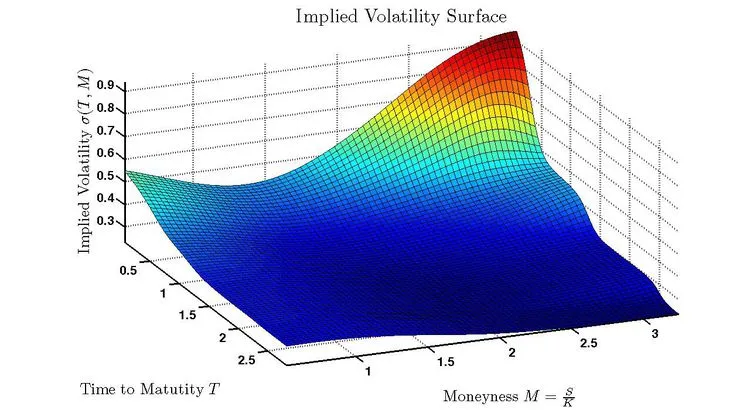

### Fenómenos que revela

**Volatility Skew — sesgo negativo**

En índices como SPY, la IV no es uniforme por strike. Los puts OTM (strikes bajos) tienen IV más alta que los calls OTM. Este patrón se llama *skew negativo* o *smirk*.

La causa es una combinación de demanda y estructura de retornos: los inversores institucionales compran puts OTM como seguro de cartera sistemáticamente, elevando su precio relativo. Al mismo tiempo, los crashes bursátiles históricos han sido más abruptos que las subidas equivalentes — el mercado aprendió a asignar más probabilidad a movimientos bruscos a la baja. Todo esto se refleja en una IV más alta para strikes bajos.

La pendiente del skew es proporcional a la probabilidad implícita de eventos de cola: un skew pronunciado significa que el mercado está pagando explícitamente por protección contra caídas extremas, más de lo que justificaría una distribución lognormal estándar.

**Term Structure — estructura temporal**

La IV varía también por vencimiento. En condiciones normales, la curva es ligeramente creciente: las opciones de largo plazo tienen IV algo mayor porque hay más incertidumbre acumulada en un horizonte más largo.

Pero en períodos de stress (VIX elevado), la curva se invierte: la IV de corto plazo sube más que la de largo porque el mercado está pricing un evento inminente específico — un dato macro, una reunión de la Fed, resultados de earnings — no incertidumbre difusa de largo plazo. Cuando la curva se invierte, es una señal clara de que el mercado espera un movimiento significativo en el corto plazo.

**Volatility Smile**

En activos como divisas (FX) o commodities, la IV es alta tanto en puts como en calls OTM, formando una curva simétrica. Ocurre cuando el mercado teme movimientos bruscos en *cualquier* dirección — por ejemplo, en un par de divisas antes de una decisión de banco central donde el resultado es binario e incierto.

Primero obtendremos una lista de fechas de expiración

In [6]:
# Filtra vencimientos: entre 7 y 400 días, primeros 8
exps = [
    e for e in tk.options
    if 7 <= (date.fromisoformat(e) - today).days <= 400
][:8]
print(f"Vencimientos: {exps}")

records = []

Vencimientos: ['2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-31', '2026-04-02', '2026-04-10', '2026-04-17']


### Construcción: datos y filtros de calidad

Para construir una superficie limpia hay que resolver dos problemas prácticos: **liquidez** y **ruido**.

Las opciones muy OTM o con vencimientos lejanos suelen tener spreads bid/ask amplios y volumen bajo. Calcular IV sobre esos precios produce valores espurios que distorsionan la superficie — los picos que se ven en superficies sin filtrar son casi siempre opciones ilíquidas. Los filtros clave son:

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

for exp in exps:
    T = (date.fromisoformat(exp) - today).days / 365

    # Calls y puts
    calls = tk.option_chain(exp).calls.copy()
    puts  = tk.option_chain(exp).puts.copy()

    for df, opt_type in [(calls, "call"), (puts, "put")]:
        # Filtros de liquidez y spread
        df = df[
            (df['bid'] > 0) &
            (df['ask'] > 0) &
            (df['volume'].fillna(0) > 5) &
            (df['ask'] / df['bid'] < 3.0) &
            (df['strike'] >= S0 * 0.80) &
            (df['strike'] <= S0 * 1.15)
        ].copy()
        df['mid'] = (df['bid'] + df['ask']) / 2

        for _, row in df.iterrows():
            K   = row['strike']
            mid = row['mid']
            try:
                iv = implied_vol(mid, S0, K, r, T, option=opt_type)
                if 0.05 <= iv <= 2.0:   # descarta IVs absurdas
                    records.append({
                        'expiry'  : exp,
                        'days'    : round(T * 365),
                        'K'       : K,
                        'moneyness': K / S0,
                        'type'    : opt_type,
                        'IV'      : iv * 100
                    })
            except Exception:
                pass

Puntos válidos: 1698


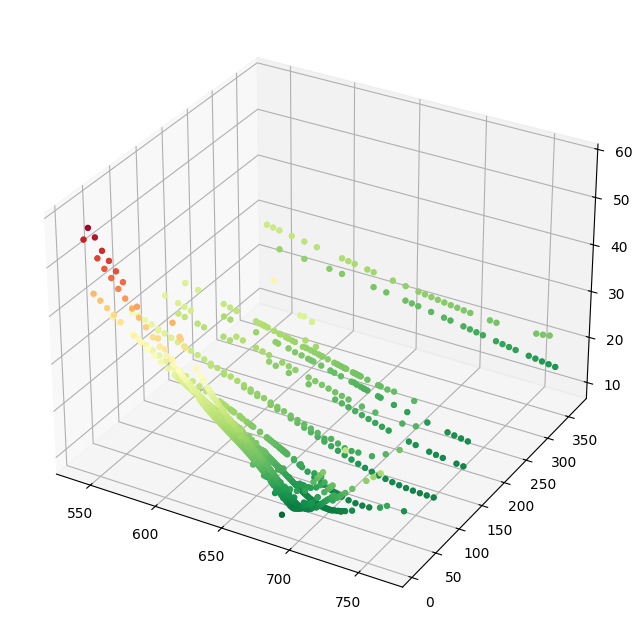

In [12]:
df_surf = pd.DataFrame(records)
print(f"Puntos válidos: {len(df_surf)}")

# Plot 3D
fig = plt.figure(figsize=(13, 8))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_surf['K'],
    df_surf['days'],
    df_surf['IV'],
    c=df_surf['IV'],
    cmap='RdYlGn_r',
    s=12,
    alpha=0.8
)

Después de calcular IV, se aplica un filtro adicional por percentil para eliminar outliers residuales que pasaron los filtros anteriores:

In [13]:
q97     = df_surf['IV'].quantile(0.97)
df_surf = df_surf[df_surf['IV'] <= q97].copy()

### Selección de vencimientos

Un error frecuente es tomar los primeros N vencimientos disponibles. que en SPY suelen estar todos agrupados en las próximas semanas (opciones semanales). Para una superficie informativa hay que **distribuir los vencimientos** a lo largo del horizonte disponible:

In [14]:
today    = date.today()
all_exps = [(e, (date.fromisoformat(e) - today).days)
            for e in tk.options
            if 7 <= (date.fromisoformat(e) - today).days <= 400]

# 8 vencimientos espaciados uniformemente entre 7 y 400 días
idx  = np.linspace(0, len(all_exps) - 1, min(8, len(all_exps)), dtype=int)
exps = [all_exps[i][0] for i in idx]

Esto garantiza puntos en el corto plazo (~1 mes), mediano (~3–6 meses) y largo (~1 año), que es donde la term structure es más informativa.

### Interpolación de la superficie

Los datos de mercado son puntos dispersos — la cadena de opciones tiene strikes discretos y un número finito de vencimientos. Para visualizar la superficie como un plano continuo se interpola sobre una grilla regular usando `griddata`:

In [16]:
# Superficie interpolada encima de los puntos
from scipy.interpolate import griddata

ki   = np.linspace(df_surf['K'].min(),    df_surf['K'].max(),    60)
ti   = np.linspace(df_surf['days'].min(), df_surf['days'].max(), 60)
KK, TT = np.meshgrid(ki, ti)
IV_grid = griddata(
    (df_surf['K'], df_surf['days']),
    df_surf['IV'],
    (KK, TT),
    method='linear'
)

## Código completo (de la gráfica)

Puntos válidos: 849


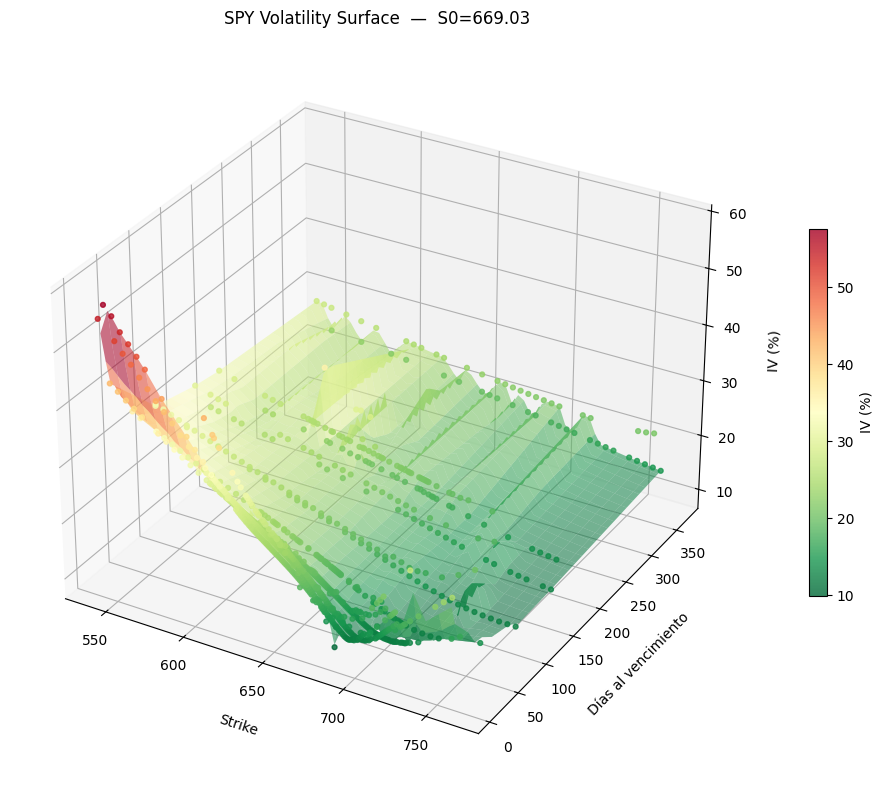

In [17]:

all_exps = [(e, (date.fromisoformat(e) - today).days)
            for e in tk.options
            if 7 <= (date.fromisoformat(e) - today).days <= 400]

# 8 vencimientos espaciados uniformemente entre 7 y 400 días
idx  = np.linspace(0, len(all_exps) - 1, min(8, len(all_exps)), dtype=int)
exps = [all_exps[i][0] for i in idx]

records = []

for exp in exps:
    T = (date.fromisoformat(exp) - today).days / 365

    # Calls y puts
    calls = tk.option_chain(exp).calls.copy()
    puts  = tk.option_chain(exp).puts.copy()

    for df, opt_type in [(calls, "call"), (puts, "put")]:
        # Filtros de liquidez y spread
        df = df[
            (df['bid'] > 0) &
            (df['ask'] > 0) &
            (df['volume'].fillna(0) > 5) &
            (df['ask'] / df['bid'] < 3.0) &
            (df['strike'] >= S0 * 0.80) &
            (df['strike'] <= S0 * 1.15)
        ].copy()
        df['mid'] = (df['bid'] + df['ask']) / 2

        for _, row in df.iterrows():
            K   = row['strike']
            mid = row['mid']
            try:
                iv = implied_vol(mid, S0, K, r, T, option=opt_type)
                if 0.05 <= iv <= 2.0:   # descarta IVs absurdas
                    records.append({
                        'expiry'  : exp,
                        'days'    : round(T * 365),
                        'K'       : K,
                        'moneyness': K / S0,
                        'type'    : opt_type,
                        'IV'      : iv * 100
                    })
            except Exception:
                pass

df_surf = pd.DataFrame(records)
print(f"Puntos válidos: {len(df_surf)}")

# Plot 3D 
fig = plt.figure(figsize=(13, 8))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_surf['K'],
    df_surf['days'],
    df_surf['IV'],
    c=df_surf['IV'],
    cmap='RdYlGn_r',
    s=12,
    alpha=0.8
)

# Superficie interpolada encima de los puntos
from scipy.interpolate import griddata

ki   = np.linspace(df_surf['K'].min(),    df_surf['K'].max(),    60)
ti   = np.linspace(df_surf['days'].min(), df_surf['days'].max(), 60)
KK, TT = np.meshgrid(ki, ti)
IV_grid = griddata(
    (df_surf['K'], df_surf['days']),
    df_surf['IV'],
    (KK, TT),
    method='linear'
)

ax.plot_surface(KK, TT, IV_grid, cmap='RdYlGn_r', alpha=0.55, linewidth=0)

ax.set_xlabel('Strike',              labelpad=10)
ax.set_ylabel('Días al vencimiento', labelpad=10)
ax.set_zlabel('IV (%)',              labelpad=10)
ax.set_title(f'{ticker} Volatility Surface  —  S0={S0:.2f}', pad=15)

fig.colorbar(scatter, ax=ax, shrink=0.5, label='IV (%)')
plt.tight_layout()
plt.show()

## Superficie resultante

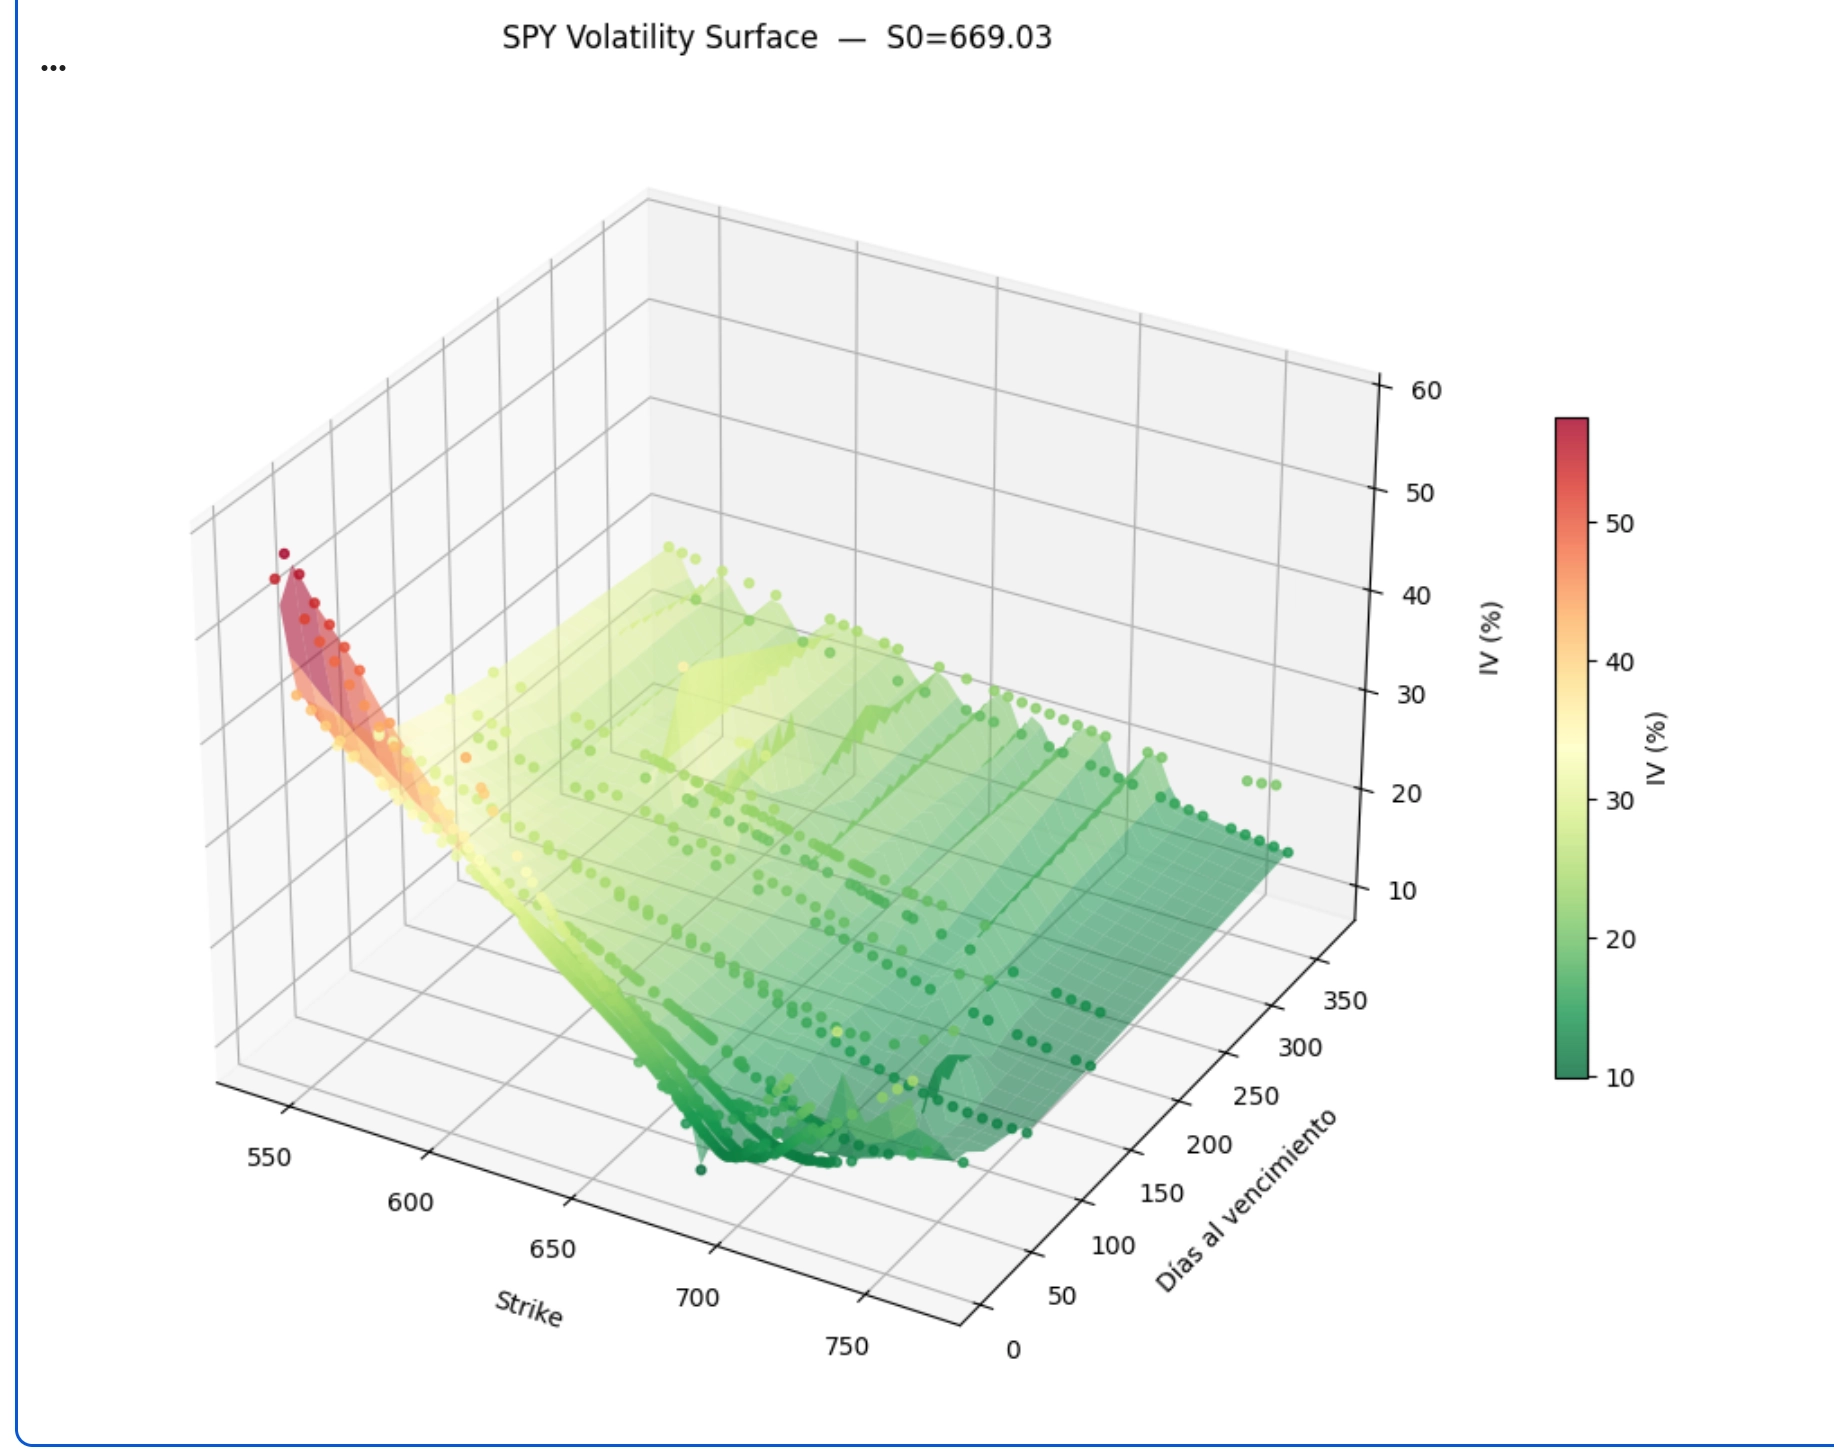

Una superficie bien construida para SPY muestra tres características visibles:

> Si la superficie tiene picos residuales o es muy irregular, puedes subir el umbral de `volume` a 20 o 50 (quitas opciones con volumenes bajos). Esto reduce el número de puntos pero mejora significativamente la calidad de la superficie.
> 

El **skew por strike** aparece como una inclinación del plano hacia la izquierda: los strikes bajos flotan más alto en el eje IV que los strikes altos. La pendiente de esta inclinación varía por vencimiento, típicamente más pronunciada en plazos cortos, donde el mercado tiene menos tiempo para “promediar” los movimientos extremos.

La **term structure** se ve como una ligera subida de la superficie en el eje de días: en condiciones normales, las opciones de largo plazo tienen IV algo mayor. Si el mercado está en stress, este eje puede estar invertido.

Los **puntos dispersos** que no siguen la superficie suave son opciones con poca liquidez que pasaron los filtros — son información real pero ruidosa. La superficie interpolada suaviza ese ruido manteniendo la forma general.

## Paridad put-call

La teoría (y la gráfica) abarca calls y puts debido a una razón profunda para eso: la **paridad put-call**. Para opciones europeas sobre el mismo subyacente, mismo strike y mismo vencimiento, existe la relación exacta:

$C - P = S - Ke^{-rT}$

Esto implica que un call y un put con el mismo $(K, T)$ **deben tener exactamente la misma IV implícita;** si no, hay arbitraje. Por eso la superficie es una sola, no dos.

## Actividad Rep 3. Checkpoint 2. Black Scholes y Volatility surface

Tabla de Volatilidades Implícitas (Entorno a K=760.0):
  Strike     Bid     Ask     Mid  IV (%)
670.0000 63.5000 63.9200 63.7100 18.7848
675.0000 60.3200 60.7500 60.5350 18.5590
680.0000 57.2000 57.5900 57.3950 18.3222
685.0000 54.1400 54.5500 54.3450 18.0949
690.0000 51.2900 51.3900 51.3400 17.8591
695.0000 48.3500 48.4500 48.4000 17.6216
700.0000 45.4700 45.5700 45.5200 17.3796
705.0000 42.6700 42.7600 42.7150 17.1379
710.0000 39.9300 40.0300 39.9800 16.8937
715.0000 37.2800 37.3800 37.3300 16.6517
720.0000 34.7100 34.8100 34.7600 16.4092
725.0000 32.2400 32.3300 32.2850 16.1709
730.0000 29.8600 29.9500 29.9050 15.9360
735.0000 27.5900 27.6700 27.6300 15.7076
740.0000 25.4100 25.5000 25.4550 15.4833
745.0000 23.3500 23.4300 23.3900 15.2664
750.0000 21.4000 21.4800 21.4400 15.0589
755.0000 19.5600 19.6400 19.6000 14.8587
760.0000 17.8400 17.9100 17.8750 14.6683
765.0000 16.2300 16.3000 16.2650 14.4882
770.0000 14.7300 14.8000 14.7650 14.3172
775.0000 13.3500 13.4200 13.3850 14.1611
78

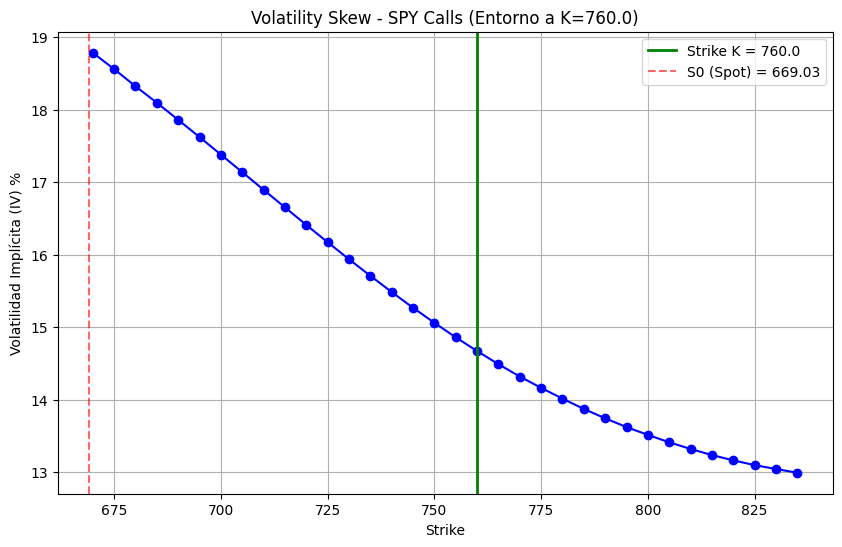

In [18]:

# 1. Definimos el rango de strikes dinámicamente basado en el Strike K (680)
lower_bound = K * 0.88
upper_bound = K * 1.10

# 2. Obtenemos la cadena de calls y la filtramos por el nuevo rango basado en K
chain = tk.option_chain(exp).calls
filtered_chain = chain[(chain['strike'] >= lower_bound) & (chain['strike'] <= upper_bound)]

strikes = []
bids = []
asks = []
mids = []
ivs = []

# 3. Iteramos sobre cada strike para extraer la IV
for index, row in filtered_chain.iterrows():
    K_val = row['strike']
    bid_val = row['bid']
    ask_val = row['ask']
    
    # Filtramos opciones sin liquidez
    if bid_val <= 0 or ask_val <= 0:
        continue
        
    # Precio mid dinámico
    mid_val = (bid_val + ask_val) / 2
    
    try:
        # Extraemos la IV usando la función de tu notebook
        iv_val = implied_vol(mid_val, S0, K_val, r, T, option="call")
        
        # Guardamos datos
        strikes.append(K_val)
        bids.append(bid_val)
        asks.append(ask_val)
        mids.append(mid_val)
        ivs.append(iv_val * 100) # Formato porcentaje
        
    except (ValueError, RuntimeError):
        continue

# 4. Construimos la tabla
df_results = pd.DataFrame({
    'Strike': strikes,
    'Bid': bids,
    'Ask': asks,
    'Mid': mids,
    'IV (%)': ivs
})

print(f"Tabla de Volatilidades Implícitas (Entorno a K={K}):")
print(df_results.to_string(index=False, float_format="%.4f"))

# 5. Construimos la gráfica enfocada en K
plt.figure(figsize=(10, 6))
plt.plot(strikes, ivs, marker='o', linestyle='-', color='b')

# Línea vertical para tu Strike objetivo K
plt.axvline(x=K, color='green', linestyle='-', linewidth=2, label=f'Strike K = {K}')

# Línea vertical opcional para S0 (para ver dónde está el mercado actual respecto a K)
plt.axvline(x=S0, color='red', linestyle='--', alpha=0.6, label=f'S0 (Spot) = {S0:.2f}')

plt.title(f'Volatility Skew - SPY Calls (Entorno a K={K})')
plt.xlabel('Strike')
plt.ylabel('Volatilidad Implícita (IV) %')
plt.legend()
plt.grid(True)
plt.show()

## Preguntas:

- **¿La curva de IV es decreciente, creciente o tiene forma de smile? ¿Qué implica eso?** *Respuesta:* Es decreciente. Implica que el mercado le tiene mucho más miedo a que el precio caiga de golpe que a que suba bruscamente.

- **¿En qué strike es mínima la IV? ¿Coincide con S0?** *Respuesta:*  Es mínima en un strike que está un poco por encima de S0. Por lo tanto, no coincide exactamente con el precio actual (S0).

- **¿Qué estarían comprando los inversores que pagan una IV alta en strikes bajos?** *Respuesta:* Están comprando protección o "seguros" contra una caída fuerte del mercado (están pagando caro por opciones Put de emergencia).

- **¿Qué le diría esta curva a alguien que quiere usar Black–Scholes con una sola volatilidad constante?** *Respuesta:* Le diría que es un error en la práctica. Si usa una sola volatilidad para todo, calculará mal los precios de las opciones: venderá muy barato el riesgo de caídas y comprará muy caro lo demás. Cada strike necesita usar su propia volatilidad.

